<a href="https://colab.research.google.com/github/sebi-varkey/AL-ML-intership/blob/main/day_3_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Day             0
dtype: int64

Summary Statistics:
              Store                 Date  Weekly_Sales  Holiday_Flag  \
count  6435.000000                 6435  6.435000e+03   6435.000000   
mean     23.000000  2011-06-17 00:00:00  1.046965e+06      0.069930   
min       1.000000  2010-02-05 00:00:00  2.099862e+05      0.000000   
25%      12.000000  2010-10-08 00:00:00  5.533501e+05      0.000000   
50%      23.000000  2011-06-17 00:00:00  9.607460e+05      0.000000   
75%      34.000000  2012-02-24 00:00:00  1.420159e+06      0.000000   
max      45.000000  2012-10-26 00:00:00  3.818686e+06      1.000000   
std      12.988182                  NaN  5.643666e+05      0.255049   

       Temperature   Fuel_Price          CPI  Unemployment         Year  \
count  6435.000000  6435.000000  64

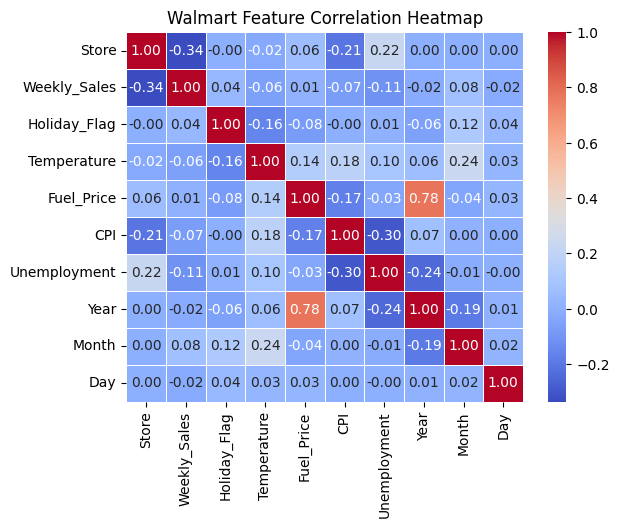

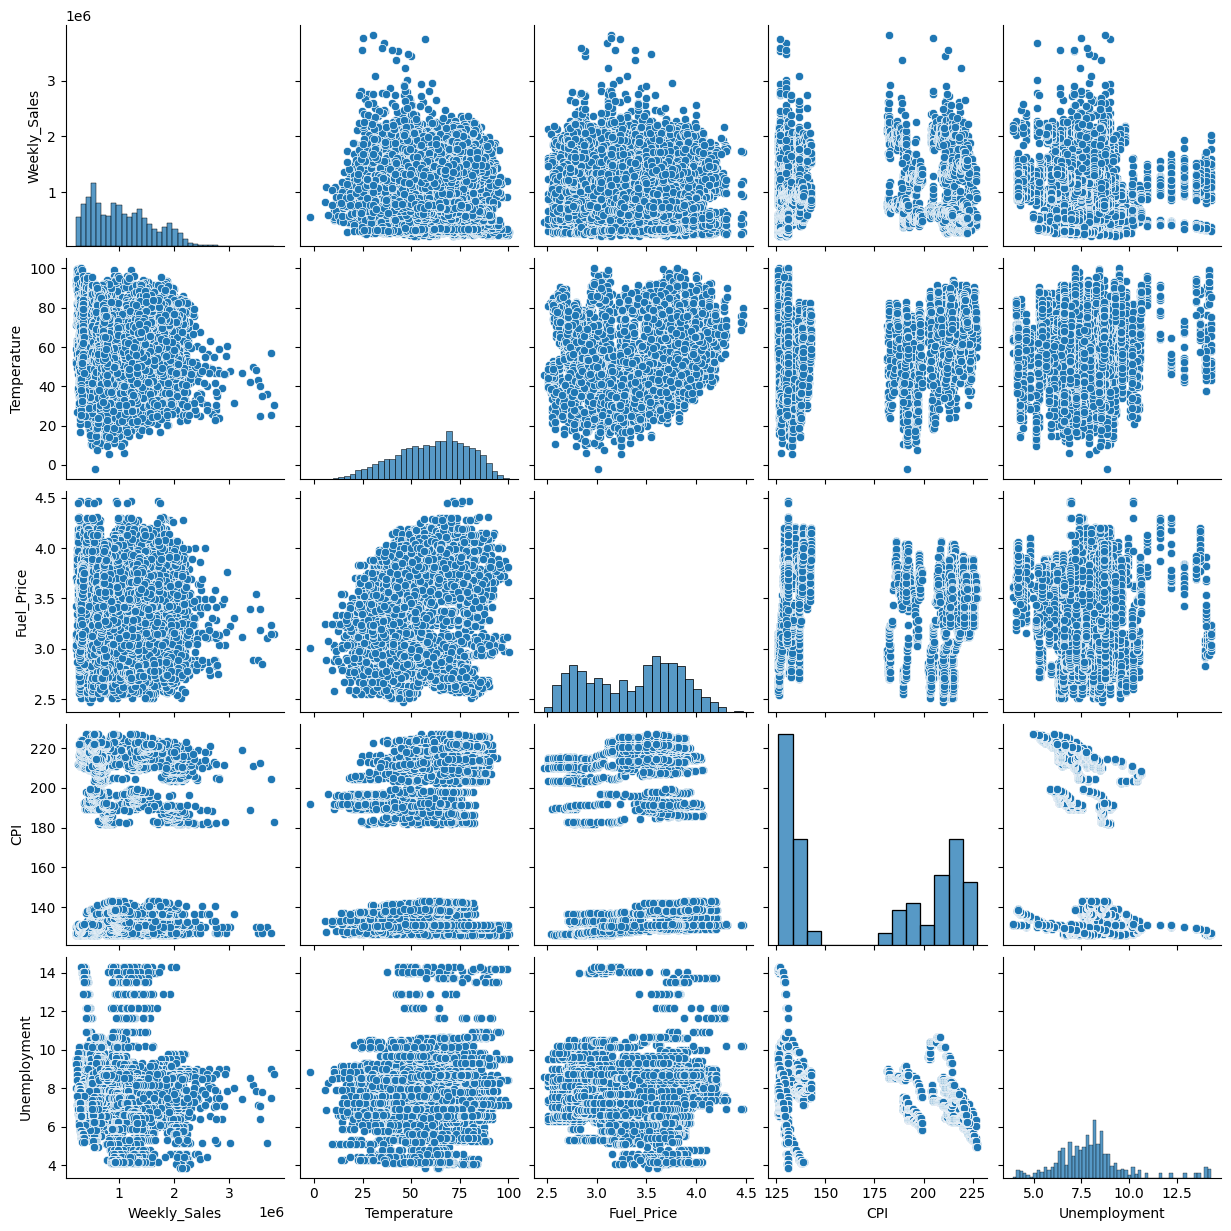

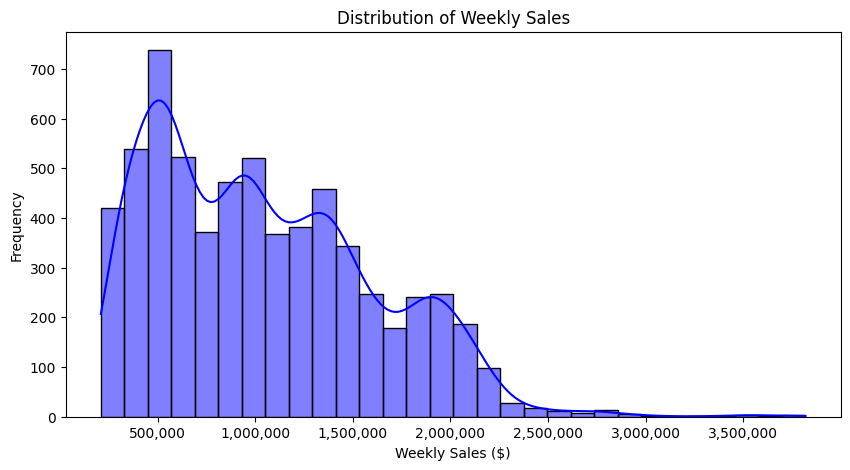

R² Score: 0.1555
RMSE: 521597.6144


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
df=pd.read_csv('/content/Walmart Data Analysis and Forcasting.csv')


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Load the dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")
df["Date"] = pd.to_datetime(df["Date"],format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day


# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

numeric_df = df.drop(columns=['Date'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Walmart Feature Correlation Heatmap")
plt.show()

# Pairplot for key variables
sns.pairplot(df[['Weekly_Sales','Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales ($)")
plt.ylabel("Frequency")
# Format x-axis with standard commas for readability with large currency numbers
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.show()

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales", "Date"])  # All columns except target
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

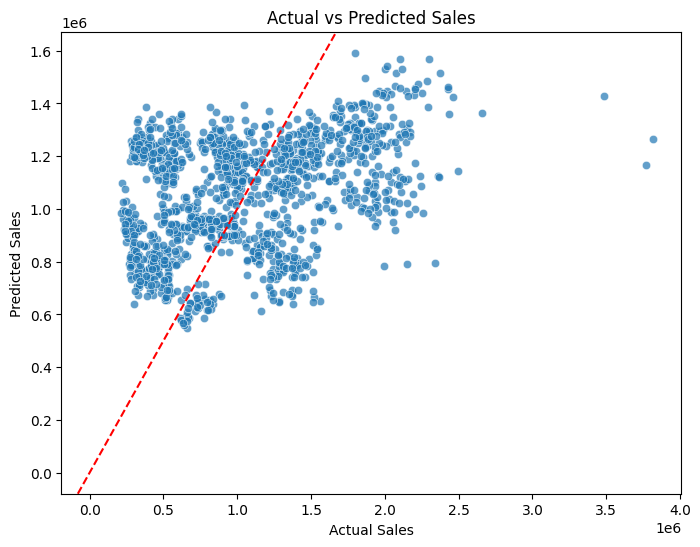

In [ ]:
#scatter plot of actual vs predicted values
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import skew

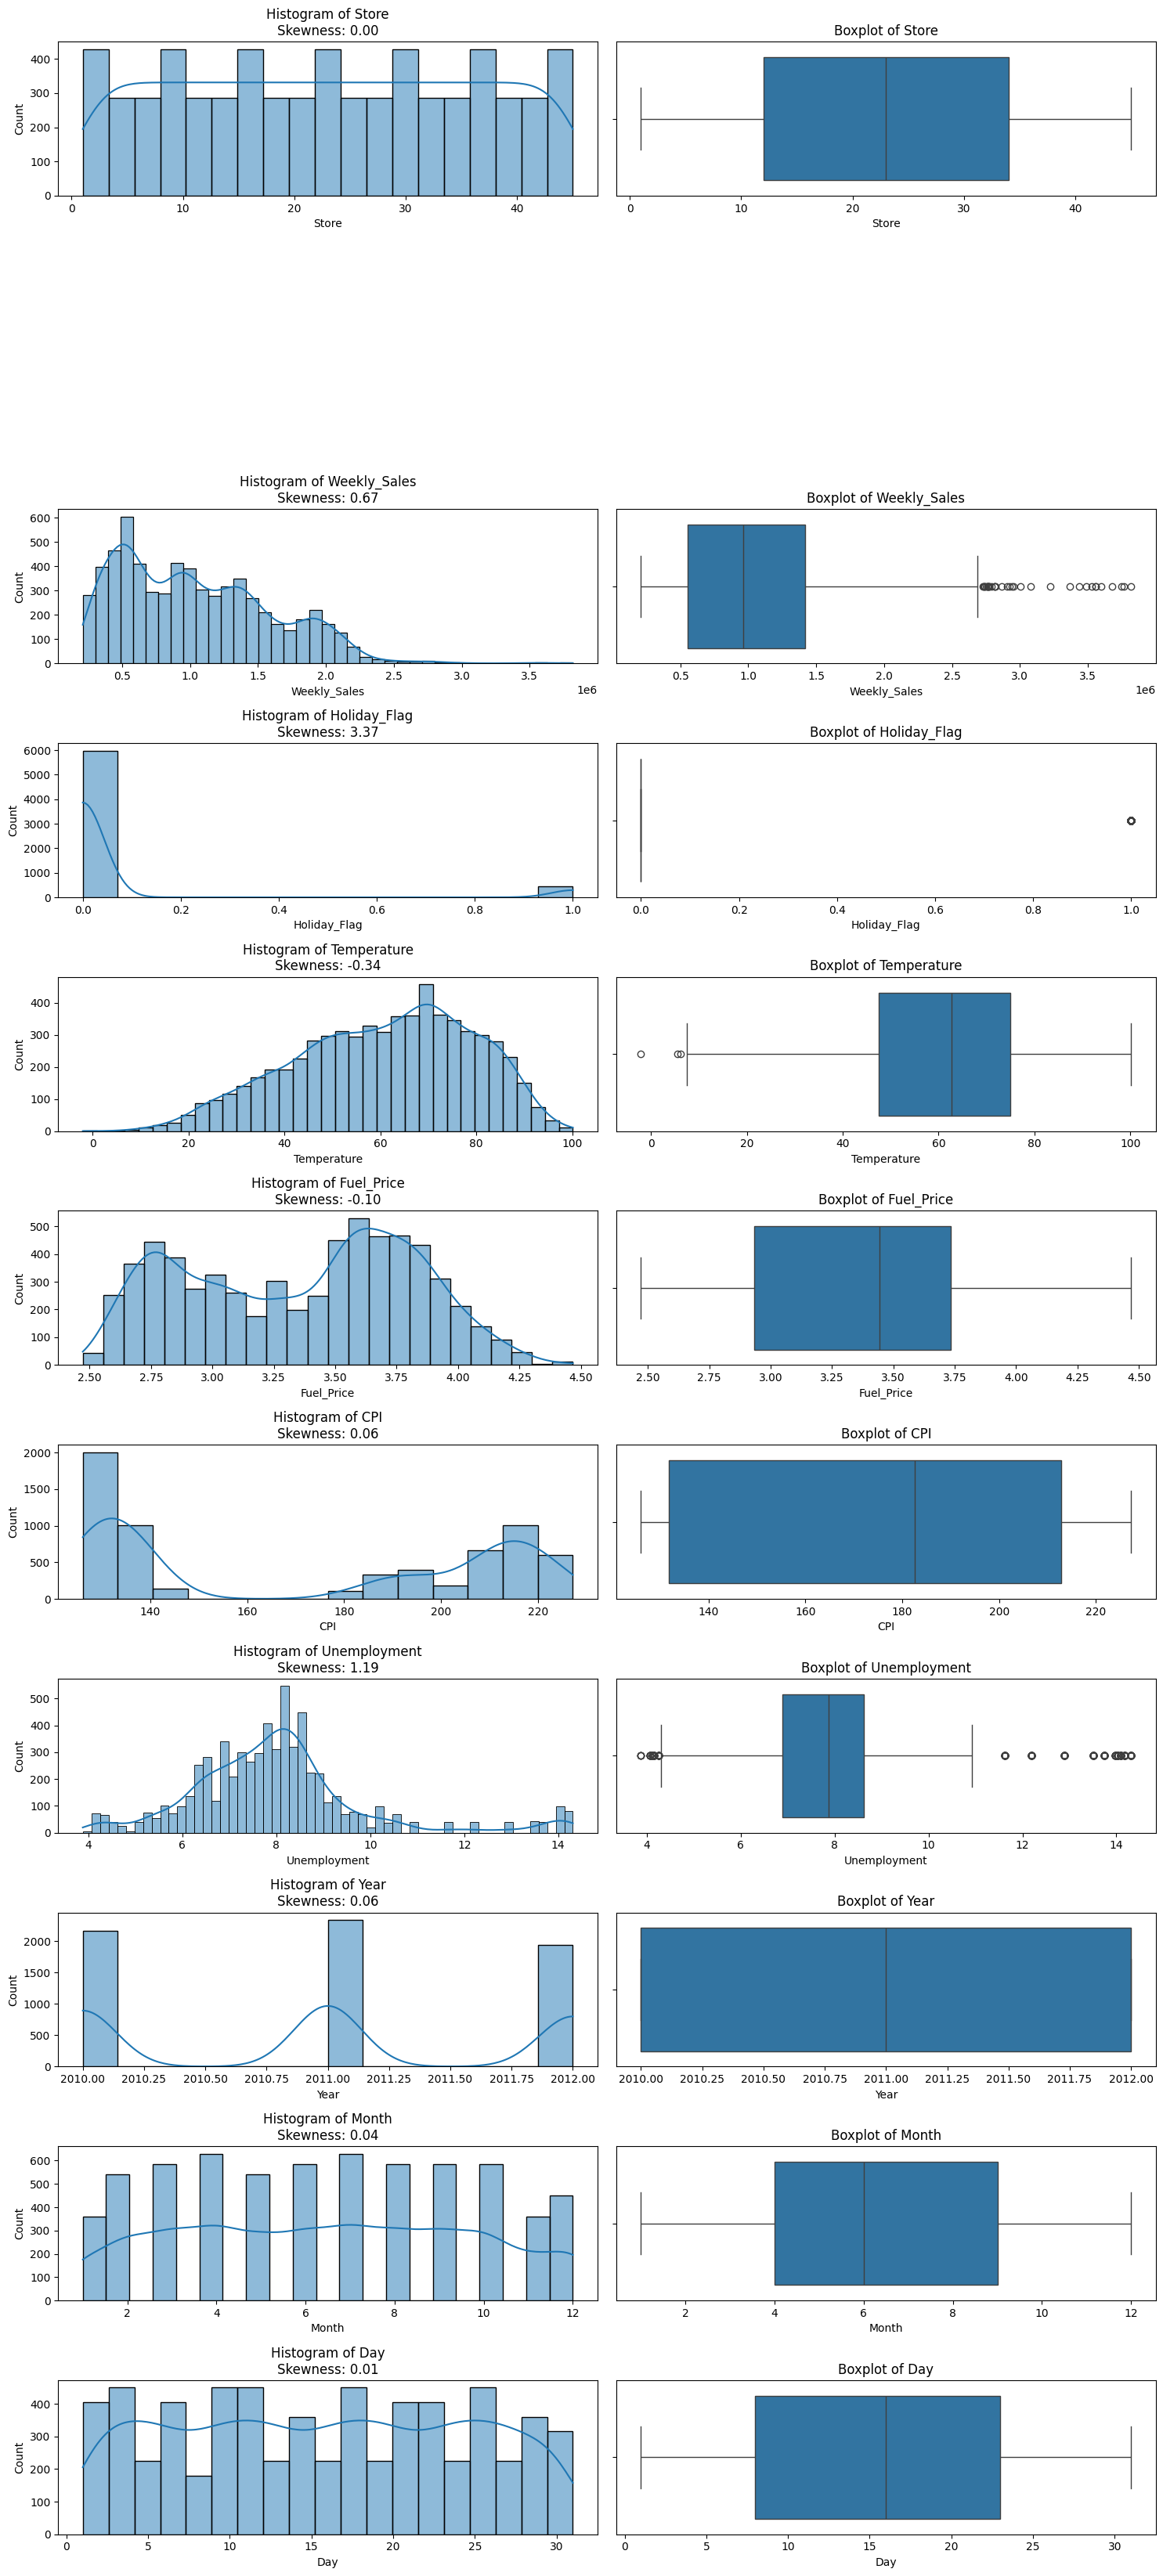

In [ ]:
skewness=df.skew(numeric_only=True)

# plot histogram and boxplots
num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols * 3))

for i, col in enumerate(df.columns):
  # Skip non-numeric columns from plotting histograms and boxplots
  if df[col].dtype != 'object' and df[col].dtype != '<M8[ns]': # Exclude object and datetime columns
    plt.subplot(num_cols,2,2*i +1)
    sns.histplot(df[col],kde=True)
    plt.title(f'Histogram of {col}\nSkewness: {skewness[col]:.2f}')

    plt.subplot(num_cols,2,2*i+2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

In [ ]:
skewed_cols=df.skew(numeric_only=True).abs()
highly_skewed = skewed_cols[skewed_cols>1].index
negatively_skewed = skewed_cols[skewed_cols<1].index
print("Highly skewed columns:\n",highly_skewed)
print("Negatively skewed columns:\n",negatively_skewed)

Highly skewed columns:
 Index(['Holiday_Flag'], dtype='object')
Negatively skewed columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment'],
      dtype='object')


In [ ]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [ ]:
df.skew(numeric_only=True)

,0
Store,-0.228157
Weekly_Sales,-0.049912
Holiday_Flag,3.373499
Temperature,-0.141684
Fuel_Price,-0.055815
CPI,0.010477
Unemployment,0.226991
Year,0.000000
Month,-0.140278
Day,-0.209117


In [ ]:
X=df.drop(columns=['Weekly_Sales', 'Date'])
y=df["Weekly_Sales"]

In [ ]:
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1336
RMSE: 0.9428


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

y_pred=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5

print(f"Random forest R²  Score: {r2:.4f}")
print(f"Random forest RMSE: {rmse:.4f}")

Random forest R²  Score: 0.9762
Random forest RMSE: 0.1563
